---
# Introduction to Data Science and Systems 2024-2025

## Week 5: Optimisation II
\- First order optimisation and gradient descent

##### University of Glasgow - material prepared by John H. Williamson (adapted to IDSS by NP/BSJ), <small>v20242025a</small>
----

By the end of this unit you should know:
* what first-order optimisation is
* how gradient descent works
* what automatic differentiation is, and why it is important for optimisation
* what the Jacobian (matrix), gradient (vector) and Hessian (matrix) are, and how they characterise the local behaviour of the objective function
* what continuity is, and how Lipschitz continuity relates to gradient descent
* how stochastic relaxation can be used to create smooth continuous objective functions from discontinuous ones
* what stochastic gradient descent is and why it is useful
* what momentum is, and how it can improve gradient descent
* what second-order methods are and their limitations



In [1]:
from __future__ import print_function, division
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
plt.rc('figure', figsize=(8.0, 4.0), dpi=140)

$$\newcommand{\vec}[1]{{\bf #1} } 
\newenvironment{examinable}{}{{\ [\spadesuit]}}
\newcommand{\real}{\mathbb{R}}
\newcommand{\expect}[1]{\mathbb{E}[#1]}
\DeclareMathOperator*{\argmin}{arg\,min}
\begin{examinable}
\vec{x}
\real
\end{examinable}
$$



----

## Dreaming of unseen images
<img src="imgs/celeba.png" width="100%">

*Image: **synthetic** celebrity faces, dreamed up in the imagination of a deep neural network. 
 From: [Progressive Growing of GANs for Improved Quality, Stability, and Variation](http://research.nvidia.com/publication/2017-10_Progressive-Growing-of)
Tero Karras, Timo Aila, Samuli Laine, Jaakko Lehtinen Submitted to ICLR 2018*

[Cool video](https://youtu.be/XOxxPcy5Gr4)




# Example: deep neural networks

**Deep learning** or **deep neural networks** have become a major part of modern machine learning research. They have had astonishing success in fields like speech recognition, machine translation, image classification and image synthesis. The basic problem of deep learning is one of finding an approximating function. In a simple model, this might work as follows: Given some observations $\vec{x}_1, \vec{x}_2, \dots, \vec{x}_n$ and some corresponding outputs $y_1, y_2, \dots, y_n$, find a function $y^\prime = f(\vec{x};\theta)$ with parameters $\theta$, such that we have 

<div class="alert alert-box alert-success">
    
$$\theta^* = \argmin_{\theta}  \sum_i ||f(\vec{x}_i;\theta)- y_i||$$
</div>

where distance is some measure of how close the output of $f$ and the expected output $y_i$ are (the specific distance used varies with the problem). The idea is that we can learn $f$ such that we can generalise the transform to $\vec{x}$ we haven't seen yet. This is obviously an optimisation problem. But deep neural networks can have *billions* of parameters - a very long $\theta$ vector. How is it possible to do optimisation in reasonable time in such a large parameter space?
*The example above has tens of millions of parameters that need to be adjusted.*

## Backpropagation

<img src="imgs/origami.jpg" width="40%">

*Origami Hummingbird by Brett Jordan is licensed under CC BY 2.0*
Rotating, translating and a simple, fixed fold can form space into arbitrarily complex shapes.


The answer is that these networks are constructed in a very simple (but clever way). A traditional neural network consists of a series of **layers**, each of which is a **linear map** (just a matrix multiply) followed by a simple, fixed nonlinear function.  Think: rotate, stretch (linear map) and fold (simple *fixed* nonlinear folding). The output of one layer is the input for the next.



<img src="imgs/network.md.png">

*Image: a 3 layer deep network. Each layer consists of a linear map $W$ applied to the input $x$ from the previous layer, followed by a fixed nonlinear function $G(\vec{x})$*

The linear map in each layer is (of course) specified by a matrix, known as the **weight matrix**. The network is completely parameterised by the entries of the weight matrices for each layer (all of the entries of these matrices can be seen as the parameter vector $\theta$). The nonlinear function $G(\vec{x})$ is  fixed for every layer and cannot vary; it is often a simple function which "squashes" the range of the output in some way (like `tanh`, `relu` or `sigmoid` -- you don't need to know these). Only the weight matrices change during optimisation.

$$\vec{y_i} = G(W_i\vec{x_i}+\vec{b_i})$$

In [2]:
# here is a neural network

# compute the prediction (output) of a 
# deep neural network 
# given a list of weight matrices

def G(x):
    return np.maximum(x, 0) # ReLU

def predict(x, weights, biases):    
    for b_i, w_i in zip(biases, weights):        
        x = G(w_i @ x + b_i)
    return x

# "all" we have to do is adjust "weights" and 
# "biases" until we get the result we want :)
# These are our parameter vector, theta

def train(x, y, w_shapes, b_shapes):
    #???
    pass

And this particular construction (under certain conditions) has the massive advantage that the **derivative** of the objective function *with respect to the weights* can be computed for every weight in the network at the same time, even when multiple layers are composed together. The algorithm that does is called *backpropagation* and  it is an algorithm for **automatic differentiation**. The "derivative with respect to the weights" means that we can tell how much of an effect each weight will have on the prediction, for every weight in the whole network, in one go.

If we imagine all of the elements of the weight matrices concatenated into a single vector $\theta$, we can get the **gradient** of the objective function w.r.t $\theta$. This makes the optimisation "easy"; we can just walk in the direction that takes us downhill fastest.

[*If you really want to understand what is going on in learning in deep networks, read [colah's blog](http://colah.github.io/posts/2015-08-Backprop/) [another colah article](http://colah.github.io/posts/2014-03-NN-Manifolds-Topology/), and [Nielsen's free book](http://neuralnetworksanddeeplearning.com/), or [Deep learning from scratch](http://www.deepideas.net/deep-learning-from-scratch-i-computational-graphs/)]*

## Why not use heuristic search?
Heuristic search methods like random search, simulated annealing and genetic algorithms are easy to understand, easy to implement and have few restrictions on the problems they can be applied to. So why not always use those approaches?

* They can be very slow; it may take many iterations to approach a minimum and require significant computation to compute each iteration.
* There is no guarantee of convergence, or even of progress. The search can get stuck, or drift slowly over plateaus.
* There are a huge number of **hyperparameters** that can be tweaked (temperature schedules, size of population, memory structure, etc.). How should these be chosen? Optimal choice of these parameters becomes an optimisation problem in itself.

For optimisation problems like deep neural networks, heuristic search is hopelessly inadequate. It is simply too slow to make progress in training networks with millions of parameters. Instead, **first-order** optimisation is applied. **First-order algorithms**, that we will discuss today, can be *orders of magnitude* faster than heuristic search.

*Note: if an objective function is known to be convex with convex constraints, there are much better methods still for optimisation, which can often run exceptionally quickly with guaranteed convergence.*




## Rolling a ball: physical optimisation

An intuition for  higher-order optimisation can be formed by considering a ball rolling on a (smooth) surface, which represents the value of the objective function across a 2D domain (i.e. if we had a parameter vector $\theta$ with two elements). 

<img src="imgs/ball.gif">

Gravity applies a vertical downward force. The surface applies a force to the ball along the direction of the *surface normal*, the vector that points "straight out" from the surface. This results in a force component in *the direction of the steepest slope* of the surface, accelerating the ball in that direction. This *gradient vector always points in the direction of the steepest slope*.

<img src="imgs/physical_opt.png" width="60%">

The ball will eventually settle in a configuration where there is a balanced set of forces applied to it. This will happen, for example, if the ball settles at a minimum where the normal of the surface is parallel with gravity.

### Attractors: flowing towards a solution

We can see this as an **attractor** that draws our search towards a solution. The trajectory of the search is parallel to the "flow field" of the objective function. Our physical intuition is that we can find minima by rolling into "basins" by following these flow lines.

<img src="imgs/streamlines.png">



---




### Jacobian: matrix of derivatives
* If $f(x)$ is a scalar function of a scalar $x$, $f^\prime(x)$ is the first derivative of $f$ w.r.t. x, i.e. $\frac{d}{dx}f(x)$. The second derivative is written $f^{\prime\prime}(x) = \frac{d^2}{dx^2}f(x)$.

* If we generalise this to a **vector** function $\vec{y}= f(\vec{x})$, then we have a rate of change (derivative) between every component of the input and every component of an output at any specific input $\vec{x}$. We can collect this derivative information into a matrix called the **Jacobian matrix**, which characterises the slope *at a specific point $\vec{x}$*. If the input $\vec{x} \in \real^n$ and the output $\vec{y} \in \real^m$, then we have an $m\times n$ matrix:

<div class="alert alert-box alert-success">
    
$$f'(\vec{x}) = \vec{J} =  \begin{bmatrix}
\frac{\partial y_0}{\partial x_0} & \frac{\partial y_0}{\partial x_1} & \dots & \frac{\partial y_0}{\partial x_n} \\
\frac{\partial y_1}{\partial x_0} & \frac{\partial y_1}{\partial x_1} & \dots & \frac{\partial y_1}{\partial x_n} \\
\dots \\
\frac{\partial y_m}{\partial x_0} & \frac{\partial y_m}{\partial x_1} & \dots & \frac{\partial y_m}{\partial x_n} \\
\end{bmatrix}
$$

</div>

This simply tells us how much each component of the output changes as we change any component of the input -- the generalised "slope" of a vector-valued function. This is a very important way of characterising the variation of a vector function at a point $\vec{x}$, and is widely used in many contexts. In the case where $f$ maps $\real^n \rightarrow \real^n$ (from a vector space to the same vector space), then we have a square $n\times n$ matrix $\vec{J}$ with which can we do standard things like compute the determinant, take the eigendecomposition or (in some cases invert).

In many cases, we have a very simple Jacobian: just one single row. This applies in cases where we have a scalar function $y = f(\vec{x})$, where $y\in\real$ (i.e. a one dimensional output from an $n$ dimensional input). This is the situation we have with a loss function $L(\theta)$ is a scalar function of a vector input. In this case, we have a single row Jacobian: the gradient vector.

---

## Gradient vector: one row of the Jacobian

* $\nabla f(\vec{x})$ is the *gradient vector* of a (scalar) function of a vector, the equivalent of the first derivative for vector functions. We have one (partial) derivative per component of $\vec{x}$. This tells us how much $f(\vec{x})$ would vary if we made tiny changes to each dimension *independently*. Note that in this course we only deal with function $f(x)$ with scalar outputs, but with vector inputs. We will work with scalar objective functions $L(\theta)$ of parameter vectors $\theta$.

<div class="alert alert-box alert-success">
    
$$\nabla L(\vec{\theta}) = \left[ \frac{\partial L(\vec{\theta})}{\partial \theta_1},  
\frac{\partial L(\vec{\theta})}{\partial \theta_2}, \dots, \frac{\partial L(\vec{\theta})}{\partial \theta_n},\right]$$
    
   

</div>

* If  $L(\theta)$ is a map $\real^n \rightarrow \real$, (i.e. a scalar function, like an ordinary objective function) then $\nabla L(\theta)$ is a vector valued map $\real^n \rightarrow \real^n$;
    * If  $L(\theta)$ was a map $\real^n \rightarrow \real^m$, then $\nabla L(\theta)$ is matrix valued map $\real^n \rightarrow \real^{m\times n}$;


$\nabla L(\theta)$  is a vector *which points in the direction of the steepest change in $L(\theta)$*.

## Hessian: Jacobian of the gradient vector
* $\nabla^2 f(\vec{x})$ is the *Hessian matrix* of a (scalar) function of a vector, the equivalent of the second derivative for vector functions.  

Following our rule above, it's just the Jacobian of a vector valued function, so we know:

* $\nabla^2 L(\theta)$ is matrix valued map $\real^n \rightarrow \real^{n\times n}$

This is important, because we can see that the second derivative even of a scalar valued function scales quadratically with the dimension of its input!

(if the original function was a vector, we'd have a Hessian tensor instead).


<div class="alert alert-box alert-success">
    
$$H(L) = \nabla \nabla L(\vec{\theta}) = \nabla^2 L(\vec{\theta}) = 
\begin{bmatrix}
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_1^2} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_1\partial \theta_2} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_1\partial \theta_3} & \dots &
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_1\partial \theta_n}\\
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_2\partial\theta_1} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_2^2} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_2\partial \theta_3} & \dots &
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_2\partial \theta_n}\\
\dots\\
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_n\partial\theta_1} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_n\partial \theta_2} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_n\partial \theta_3} & \dots &
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_n^2}\\
\end{bmatrix},$$

</div>

### Differentiable objective functions 
For some objective functions, we can compute the (exact) **derivatives** of the  objective function with respect to the parameters $\theta$. For example, if the objective function has a single scalar parameter $\theta \in \real$ and the function is:
$$L(\theta) = \theta^2$$
then, from basic calculus, the derivative with respect to $\theta$ is just:
$$L^\prime(\theta) = 2\theta.$$

If we know the derivative, we can use this to move in "good directions" -- down the slope of the objective function towards a minimum.

This becomes slightly more involved for multidimensional objective functions (where $\theta$ has more than one component) where we have a **gradient vector** instead of a simple scalar derivative (written $\nabla L(\theta)$). However, the same principle applies.

#### Orders: zeroth, first, second
Iterative algorithms can be classified according to the order of derivative they require:
* a **zeroth order**  optimisation algorithm only requires evaluation of the objective function $L(\theta)$. Examples include random search and simulated annealing.

* a **first order**  optimisation algorithm requires evaluation of $L(\theta)$ and its derivative $\nabla L(\theta)$. This class includes the family of **gradient descent** methods.

* a **second order** optimisation algorithm requires evaluation $L(\theta)$, $\nabla L(\theta)$ and $\nabla \nabla L(\theta)$. These methods include **quasi-Newtonian** optimisation.

# Optimisation with derivatives
If we know (or can compute) the **gradient** an objective function, we know the **slope** of the function at any given point. This gives us both:
* the direction of fastest increase and
* the steepness of that slope. 

This is  *the* major application of calculus. 

Knowing the derivative of the objective function is sufficient to dramatically improve the efficiency of optimisation. 

## Conditions

### Differentiability
A **smooth function** has continuous derivatives up to some order. Smoother functions are typically easier to do iterative optimisation on, because small changes in the current approximation are likely to lead to small changes in the objective function. We say a function is **$C^n$ continuous** if the $n$th derivative is continuous.

<img src="imgs/continuity.png">

*Image: left-to-right, top-to-bottom discontinuous, $C^0$, $C^1$, $C^2$ continuous functions*

There is a difference between *having continuous derivatives* and *knowing what those derivatives are*. 

First order optimisation uses the (first) **derivatives of the objective function with respect to the parameters**. These techniques can only be applied if the objective function is:
* At least **$C^1$ continuous** i.e. no step changes anywhere in the function or its derivative
* **differentiable** i.e. gradient is defined everywhere

(though we will see that these constraints can be relaxed a bit in practice).

Many objective functions satisfy these conditions, and first-order methods can be vastly more efficient than zeroth-order methods. For particular classes of functions (e.g. convex) there are known bounds on number of steps required to converge for specific first-order optimizers.

### Lipschitz continuity

First-order (and higher-order) continuous optimisation algorithms put a stronger requirement on functions than just $C^1$ continuity and require the function to be **Lipschitz continuous**.

For functions $\real^n \rightarrow \real$ (i.e. the objective functions $L(\theta)$ we are concerned with), this is equivalent to saying that the *gradient is bounded* and the function cannot change more quickly than some constant; there is a maximum steepness.  $ \frac{\partial L(\theta)}{\partial \theta_i} \leq K $ for all $i$ and some fixed $K$.

#### Small Lipschitz constant
<video src="imgs/smooth_lipschitz.mp4" controls="true" width="50%">
    

*Video: the white cone never intersects the function, no matter where it is slid along the function. This function is Lipschitz continuous; the gradient is bounded everywhere, so that nowhere is steep enough that it intersects the cone.*
#### Large Lipschitz constant
<video src="imgs/lipschitz_big.mp4" controls="true" width="50%">

### Lipschitz constant
We can imagine running a cone of a particular steepness across a surface. We can check if it ever touches the surface. This is a measure of how steep the function is; or equivalently the bound of the first derivative. The **Lipschitz constant** $K$ of a function $f(x)$ is a measure of wide this cone that only touches the function once is. This is a measure of how smooth the function is, or equivalently the maximum steepness of the objective function at any point anywhere over its domain. It can be defined as:

$$K = \sup \left[\frac{ |f(x)-f(y)|}{|x-y|}\right],$$

where $\sup$ is the supremum; the smallest value that is larger than (or equal to) every value of this function.

A smaller $K$ means a function that is smoother. $K=0$ is totally flat. We will assume that the functions we will deal with have some finite $K$, though its value may not be precisely known.

## Analytical derivatives
If we have **analytical derivatives** (i.e. we know the derivative of the function in closed form; we can write down the maths directly), you will probably remember the "high school" process for mathematical optimisation:
* compute the derivative $f^\prime(x) = \frac{d}{dx}f(x)$
* solve for the derivative being zero (i.e. solve $x$ for $f^\prime(x)=0$). This finds all **turning points** or **optima** of the function.
* then check if any of the solutions has positive second derivative $f^{\prime \prime}(x)>0$, which indicates the solution is a minimum.
### Example
This is how we might find the minimum of $$f(x) = x^4 -40x^2 -100x.$$ The derivative is: $$f^\prime(x) = 4x^3 - 80x - 100$$ and the second derivative is $$f^{\prime\prime}(x) = 12x^2 - 80.$$ We can solve for: $$f^\prime(x) = 4x^3-20x-100 = 0,$$ and check the sign of $$f^{\prime\prime}(x) = 12x^2 -20$$ to find if we have a minimum. 

0.0 220.0


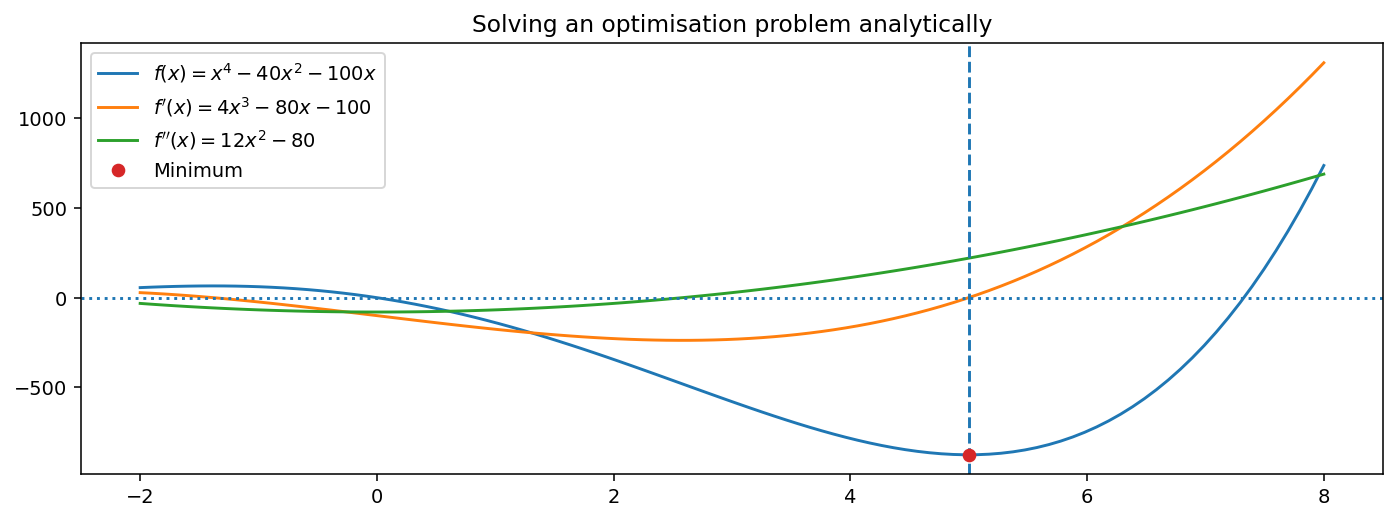

In [3]:
f = lambda x:x**4 - 40*x**2 - 100*x 
df = lambda x:4*x**3 - 80*x - 100
ddf = lambda x:12*x**2-80

x = np.linspace(-2,8,100)
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1,1,1)
ax.plot(x, f(x), label="$f(x)=x^4 -40x^2 -100x$")
ax.plot(x, df(x), label="$f^\prime(x)=4x^3 - 80x - 100$")
ax.plot(x, ddf(x), label="$f^{\prime\prime}(x)= 12x^2 - 80$")

# solution is 5.0 by inspection
ax.axhline(0, ls=':')
ax.axvline(5.0, ls='--')
ax.plot(5.0, f(5.0), 'o', label='Minimum')
ax.legend()
ax.set_title("Solving an optimisation problem analytically")
print(df(5.0), ddf(5.0))
plt.show()


---

## Computable exact derivatives
The analytical derivative approach doesn't require any iteration at all. We get the solution immediately on solving for the derivative. But usually we don't have a simple solution for the derivative, but we can evaluate the derivative *at a specific point*; we have **exact pointwise derivatives**. We can evaluate the function $f^\prime(x)$ for any $x$ but not write it down in closed form. In this case, we can still dramatically accelerate optimisation by taking steps such that we "run downhill" as fast as possible. This requires that we can compute the gradient at any point on the objective function. 

## Gradient: A derivative vector

We will work with objective functions that take in a vector and output a scalar:

```
    # vector -> scalar
    def objective(theta): 
        ...
        return score
```

We want to be able to *generate* functions:

``` 
    # vector -> vector
    def grad_objective(theta):
        ...
    return score_gradient
```    

Mathematically, we can write the vector of derivatives as: 

<div class="alert alert-success alert-box">
    
$$
\nabla L(\vec{\theta}) = \left[ \frac{\partial L(\vec{\theta})}{\partial \theta_1},  
\frac{\partial L(\vec{\theta})}{\partial \theta_2}, \dots, \frac{\partial L(\vec{\theta})}{\partial \theta_n},\right]
$$

</div>

Note: $\frac{\partial L(\vec{\theta})}{\partial \theta_1}$ just means the change in $L$ in the direction $\theta_1$ at the point $\vec{\theta}$.

This vector $\nabla L(\vec{\theta})$ is called the **gradient** or **gradient vector**. At any given point, the gradient of a function points in the direction where the function *increases fastest*. The magnitude of this vector is the rate at which the function is changing ("the steepness").

## Gradient descent

The basic first-order algorithm is called **gradient descent** and it is very simple, starting from some initial guess $\theta^{(0)}$:

<div class="alert alert-success alert-box">
    
$$\vec{\theta^{(i+1)}} = \vec{\theta^{(i)}} - \delta \nabla L(\vec{\theta^{(i)}})$$    
</div>    

where $\delta$ is a scaling hyperparameter -- the **step size**. The **step size** might be fixed, or might be chosen adaptively according to an algorithm like *line search*.

This means is that the optimiser will make moves where the objective function drops most quickly.

In simpler terms:

* starting somewhere $\theta^{(0)}$
* repeat:
    * check how steep the ground is in each direction $v = \nabla L(\vec{\theta^{(i)}})$
    * move a little step $\delta$ in the steepest direction $v$ to find $\vec{\theta^{(i+1)}}$.

Notation note: $\vec{\theta^{(i)}}$ does not mean the $i$th power of $\theta$ but just the $i$th $\vec{\theta}$ in a sequence of iterations: $\vec{\theta}^{(0)}, \vec{\theta}^{(1)}, \vec{\theta}^{(2)}, \dots$

### Downhill is not always the shortest route
While gradient descent *can* be very fast, following the gradient is not necessarily the fastest route to a minimum. In the example below, the route from the red point to the minimum is very short. Following the gradient, however, takes a very circuitous path to the minimum.

<img src="imgs/gradient_problems.png">

*Image: gradient descent means following the steepest slope -- not always the shortest route*

It is generally much faster than blindly bouncing around hoping to get to the bottom, though!

## Implementing gradient descent
The implementation follows directly from the equations:

In [38]:
import utils.history
import importlib as imp; imp.reload(utils.history)
from utils.history import History

# 
# note: fixed step size isn't a good idea!

def gradient_descent(L, dL, 
                     theta_0, 
                     delta, tol=1e-4):
    """
     L: scalar loss function
     dL: gradient of loss function w.r.t parameters
     theta_0: starting point
     delta: step size
     tol: termination condition; 
         when change in loss is less than tol, stop iterating
     """
    theta = np.array(theta_0) # copy theta_0    
    o = History()    
    o.track(np.array(theta), L(theta))
    
    # while the loss changes
    while np.sum(np.abs(dL(theta)))>tol:
        # step along the derivative        
        theta += -delta * dL(theta)        
        o.track(np.array(theta), L(theta))        
        
    return o.finalise()

In [5]:
def L(theta):
    return theta**2

def dL(theta):
    # we can differentiate L(theta) in our heads :)
    return 2*theta

In [6]:
def plot_gradient_descent(xs, L, dL, x_0, step):
    # do descent
    res = gradient_descent(L, dL, x_0, step)
    
    # plot
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)    
    ax.fill_between(xs, L(xs), label="Objective function")    
    ax.set_title("Step size=%f" % step)
    ax.set_xlabel("$\\theta_1$")
    ax.set_ylabel("Loss")
    ax.plot(res.best_thetas, res.best_losses, 'k-x', label='Steps')
    ax.legend()
    print("Converged in {0} steps".format(res.iters))
    plt.show()

xs = np.linspace(-10,10,200)

Converged in 19 steps


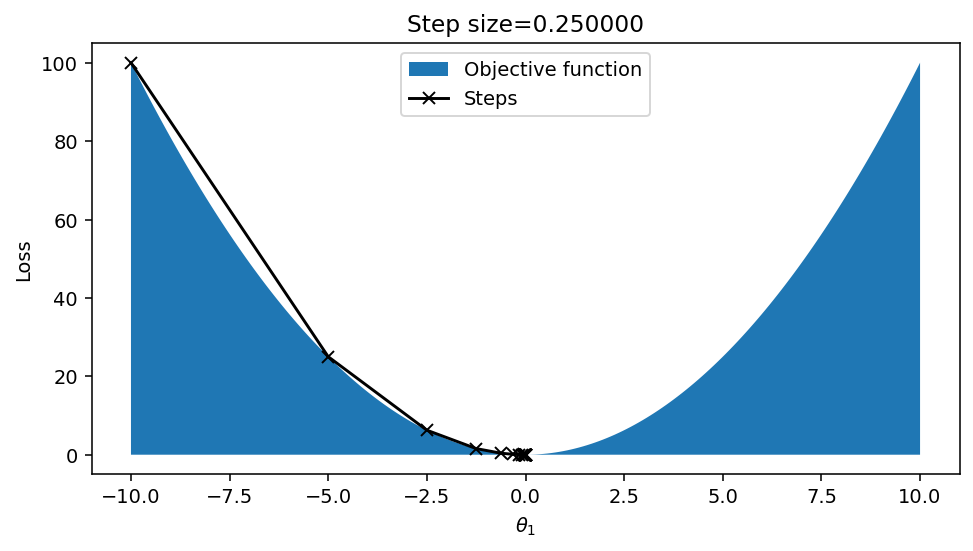

In [7]:
plot_gradient_descent(xs, L, dL, [-10.], 0.25)

### Why step size matters
The step size $\delta$ is critical for success. If it is too small, the steps will be very small and convergence will be slow. If the steps are too large, the behaviour of the optimisation can become quite unpredictable. This happens if the gradient functions changes significantly over the space of a step (e.g. if the gradient changes sign across the step).

Converged in 606 steps


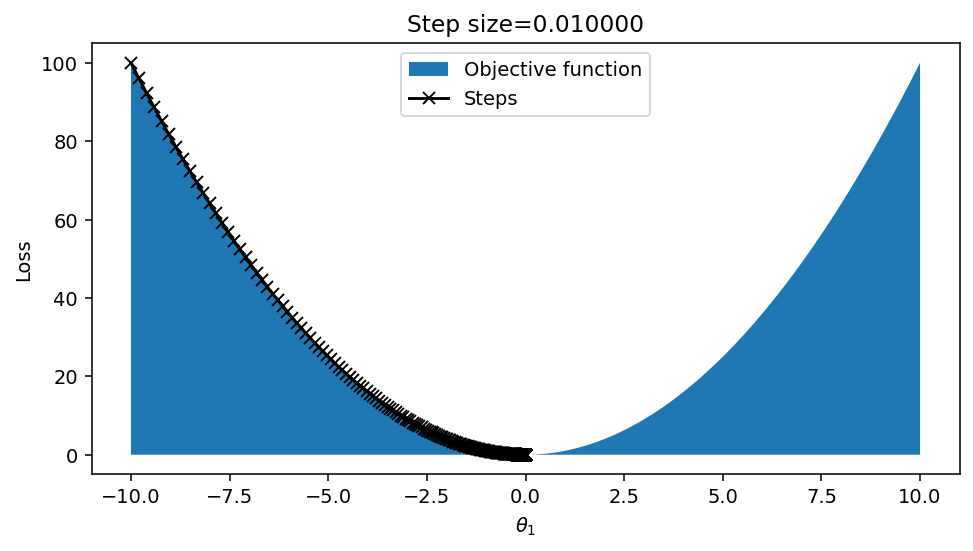

In [8]:
## too slow
# step = 0.01
plot_gradient_descent(xs, L, dL, [-10.], 0.01)

Converged in 2 steps


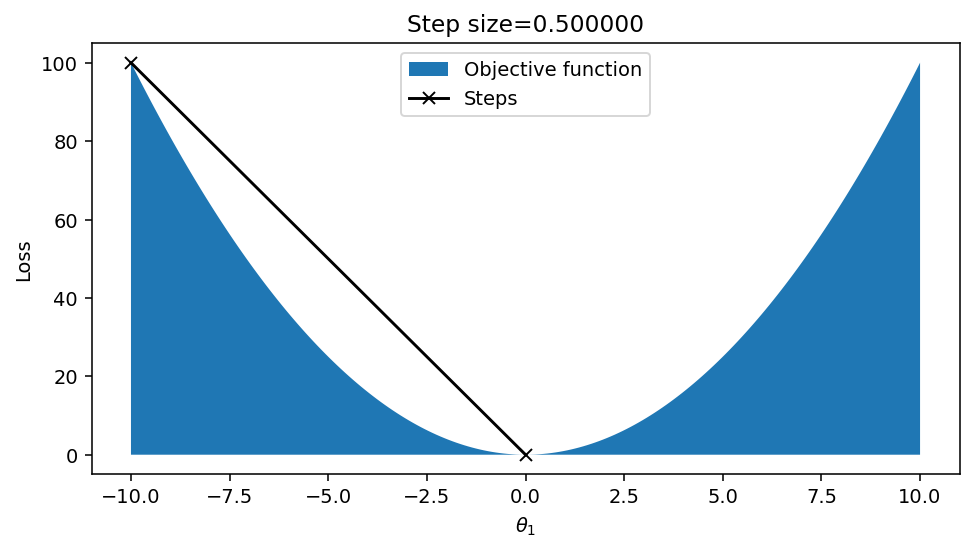

In [9]:
# perfect :)
# step = 0.5
plot_gradient_descent(xs, L, dL, [-10.], 0.5)

Converged in 301 steps


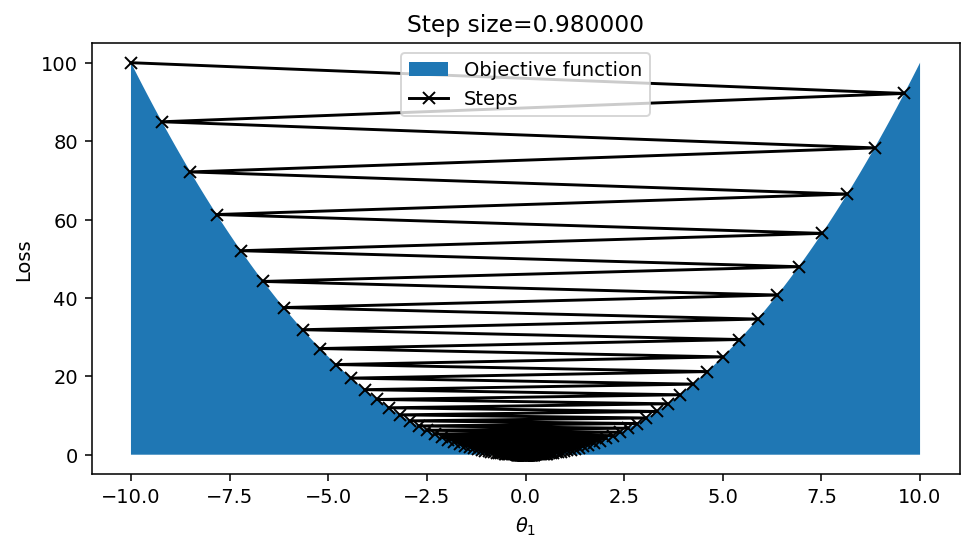

In [10]:
# too fast -- oscillation occurs
plot_gradient_descent(xs, L, dL, [-10.], 0.98)

/tmp/ipykernel_5100/552418390.py:2: RuntimeWarning: overflow encountered in square
  return theta**2
/mnt/c/Users/nicol/OneDrive - University of Glasgow/Lectures/2025-26/IDSS/Lectures/L5 - Optimisation II/utils/history.py:81: RuntimeWarning: invalid value encountered in subtract
  self.loss_change = self.last_loss - loss
/tmp/ipykernel_5100/552418390.py:6: RuntimeWarning: overflow encountered in multiply
  return 2*theta
/tmp/ipykernel_5100/1989288910.py:26: RuntimeWarning: invalid value encountered in add
  theta += -delta * dL(theta)


Converged in 1023 steps


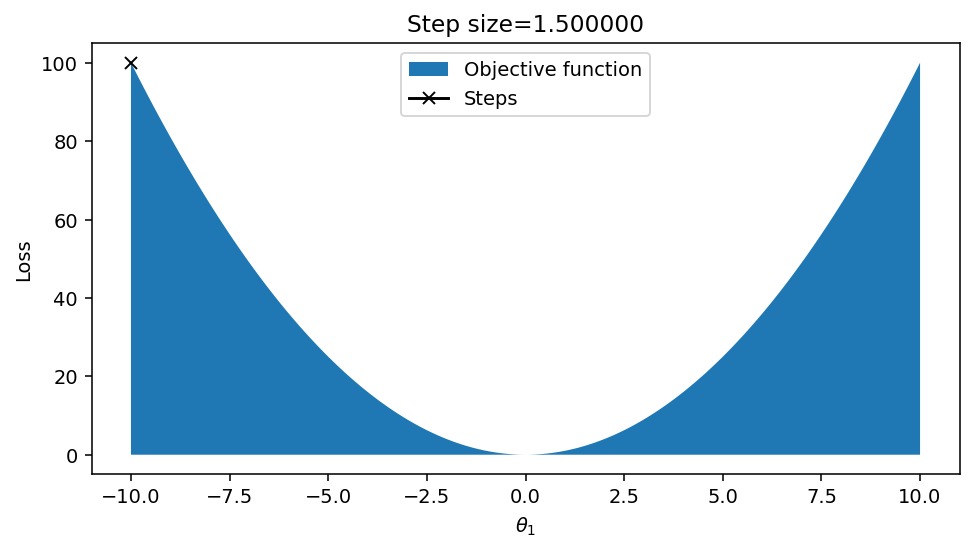

In [11]:
# way too fast -- diverges
plot_gradient_descent(xs, L, dL, 
                      [-10.], 1.5)


### Relationship to Lipschitz constant
We won't show this, but the optimal step size $\delta$ is directly related to the Lipschitz constant $K$ of the objective function. Unfortunately we rarely know $K$ precisely in many real-world optimisation tasks, and step size is often set by approximate methods like line search.

### Gradient descent in 2D
This technique extends to any number of dimensions, as long as we can get the gradient vector at any point in the parameter space. We just have a gradient vector $\nabla L(\theta)$ instead of a simple 1D derivative. There is no change to the code.


In [12]:
# test gradient descent in 2D
# you don't need to understand this code

### create a test function
from numpy.polynomial import polynomial

# a compact way of writing
# y^2 - 0.02y^3 + 5x + x^2 + 0.04x^3
poly = np.array([[0,0,1,-0.02], 
                 [5,0,0,0], 
                 [1,0,0,0],
                 [0.04,0,0,0]])

# we can take the derivative exactly,
# since polynomial functions have known analytic derivative
# this function does this for us -- 
# it is a very simple array operation
der_x, der_y = (polynomial.polyder(poly, axis=0),
               polynomial.polyder(poly, axis=1))

# loss
def L(x):
    return polynomial.polyval2d(x[0], x[1], poly)    

# note that the gradient has two components, 
# because its a 2D function
def dL(x):
    return np.array([polynomial.polyval2d(x[0], x[1], der_x), 
                     polynomial.polyval2d(x[0], x[1], der_y)])

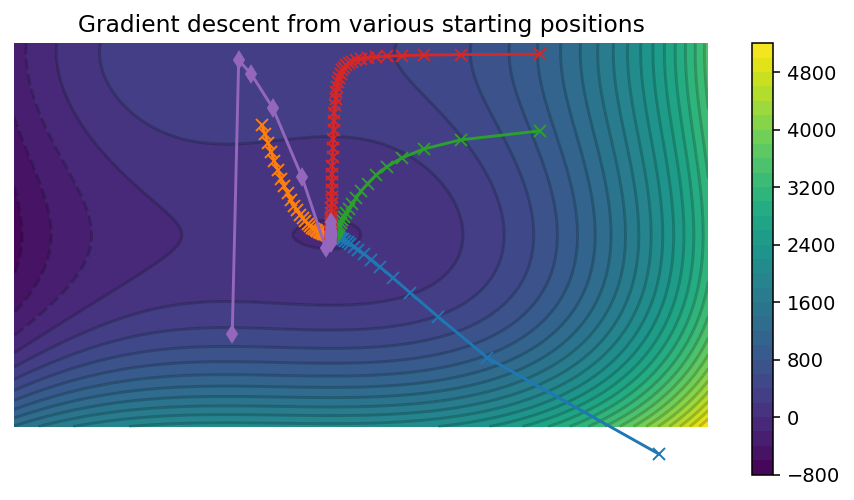

In [13]:
# plot the surface
div = np.linspace(-35,35,100)
mx, my = np.meshgrid(div, div)
mz = L([mx, my])

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
contour = ax.contourf(mx, my, mz, 32)
ax.contour(mx, my, mz, 30, colors='k', alpha=0.2)


# now plot some optimisation histories
# using gradient descent
# all of them with the same fixed size
res = gradient_descent(L, dL, [30.0,-40.0], 0.1, tol=1e-6)
history = res.best_thetas

ax.plot(history[:,0], history[:,1], 'C0-x')

res = gradient_descent(L, dL, [-10.0,20.0], 0.1, tol=1e-6)
history = res.best_thetas
ax.plot(history[:,0], history[:,1], 'C1-x')
    
res = gradient_descent(L, dL, [18.0,19.0], 0.1, tol=1e-6)
history = res.best_thetas
ax.plot(history[:,0], history[:,1], 'C2-x')

res = gradient_descent(L, dL, [18.0,33.0], 0.1, tol=1e-6)
history = res.best_thetas
ax.plot(history[:,0], history[:,1], 'C3-x')


res = gradient_descent(L, dL, [-13.0,-18.0], 0.9, tol=1e-6)
history = res.best_thetas
ax.plot(history[:,0], history[:,1], 'C4-d')
ax.axis("off")
ax.set_title("Gradient descent from various starting positions")
fig.colorbar(contour)
plt.show()

## Gradients of the objective function
For first-order optimisation to be possible, the derivative of the objective function has to be available. This obviously does not apply directly to empirical optimisation (e.g. real world manufacturing where the quality of components is being tested in an experiment -- there are no derivatives), but it can be applied in many cases where we have a computational model that can be optimised. This is again a reason to favour building models when optimising.

### Why not use numerical differences?
The definition of differentiation of a function $f(x)$ is the well known formula:
<div class="alert alert-success alert-box">
    
$$
\frac{d}{dx}f(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x-h)}{2h}
$$
</div>

Given this definition, why do we need to know the *true derivative* $\nabla L(\theta)$ if we can evaluate $L(\theta)$ anywhere? Why not just evaluate $L(\theta+h)$ and $L(\theta-h)$ for some small $h$? This approach is called numerical differentiation, and these are **finite differences**. 

This works fine for reasonably smooth one-dimensional functions:

/tmp/ipykernel_5100/2637288883.py:5: RuntimeWarning: divide by zero encountered in log
  return x**(np.cos(x)-1) * (np.cos(x)-x*np.log(x)*np.sin(x))
/tmp/ipykernel_5100/2637288883.py:5: RuntimeWarning: invalid value encountered in multiply
  return x**(np.cos(x)-1) * (np.cos(x)-x*np.log(x)*np.sin(x))
/tmp/ipykernel_5100/2637288883.py:2: RuntimeWarning: invalid value encountered in power
  return x**(np.cos(x))


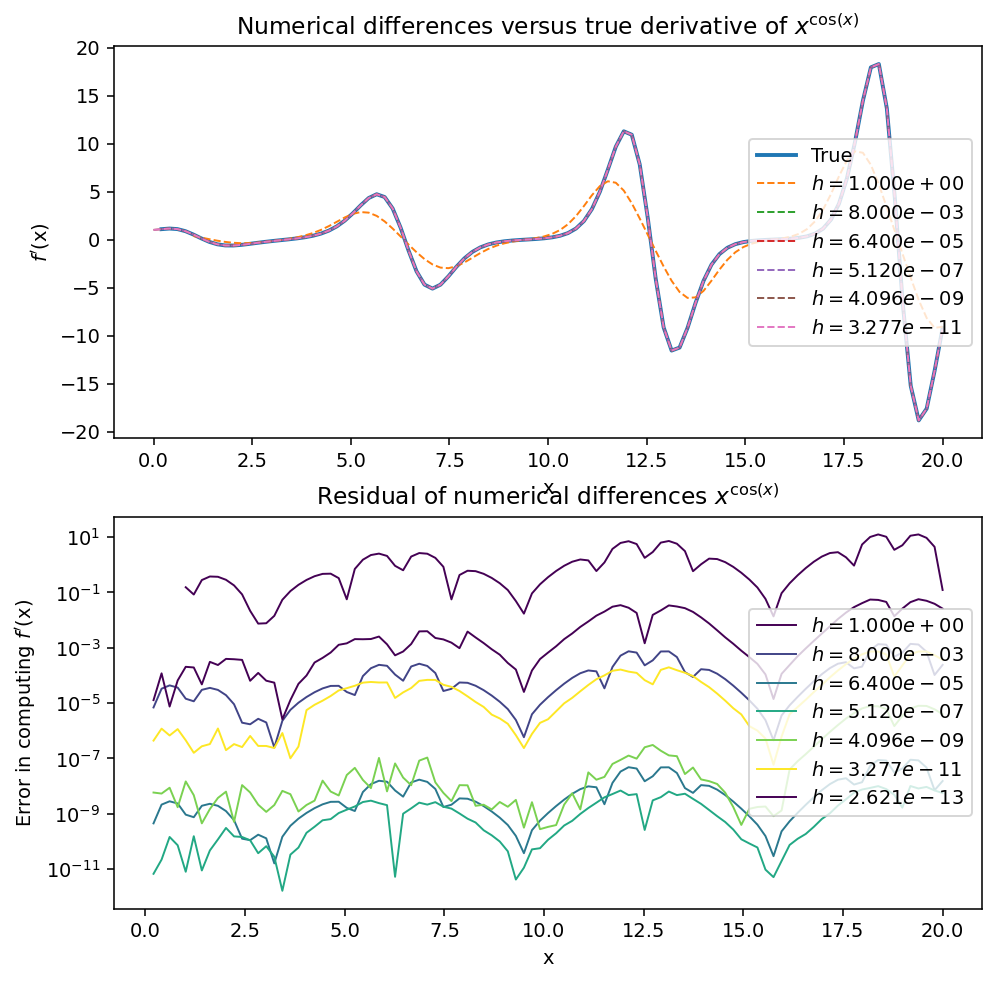

In [14]:

def f(x):
    return x**(np.cos(x))

def df(x): # true, exact derivative
    return x**(np.cos(x)-1) * (np.cos(x)-x*np.log(x)*np.sin(x))

# finite differences
def approx_d(f, x, delta=1e-4):
    return (f(x+delta) - f(x-delta)) / (2*delta)


# plot the results over the range -10, 10
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(2,1,1)
x = np.linspace(0,20, 100)

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0,1,6)))



## Plot the derivative and its approximate form
ax.plot(x,df(x), label="True",lw=2)
for d in range(0,18,3):    
    ax.plot(x,approx_d(f, x, delta=5**-d), ls='--', lw=1, label="$h=%.3e$"%(5**-d))
    
ax.legend(loc='right')
ax.set_title("Numerical differences versus true derivative of $x^{\cos(x)}$")
ax.set_xlabel("x")
ax.set_ylabel("$f^\\prime$(x)")

## Plot the residuals
ax = fig.add_subplot(2,1,2)


for d in range(0,20,3):    
    # adjust to 20 to see numerical issues
    d = d  
    ax.plot(x,np.abs(df(x)-approx_d(f, x, delta=5**-d)), ls='-', lw=1, label="$h=%.3e$"%(5**-d))
    
ax.set_yscale("log")    
ax.legend(loc='right')
ax.set_title("Residual of numerical differences $x^{\cos(x)}$")
ax.set_xlabel("x")
ax.set_ylabel("Error in computing $f^\\prime$(x)")
plt.show()


### Numerical problems
It is also difficult to choose $h$ such that the function is not misrepresented by an excessive value but numerical issues do not dominate the result. Remember that finite differences violates *all* of the rules for good floating point results:
$$\frac{f(x+h) - f(x-h)}{2h}$$

* (a) it adds a small number $h$ to a potentially much larger number $x$ *(magnitude error)*
* (b) it then subtracts two very similar numbers $f(x+h)$ and $f(x-h)$  *(cancellation error)*
* (c) then it divides the result by a very small number $2h$ *(division magnification)*

It would be hard to think of a simple example that has more potential numerical problems than finite differences!

### Revenge of the curse of dimensionality
This is not useful in high dimensions, even if we can deal with numerical issues, however. The **curse of dimensionality** strikes once again. To evaluate the *gradient* at a point $\vec{x}$ we need to compute the numerical differences in *each* dimension $x_i$. If $\vec{\theta}$ has one million dimensions, then *each* individual derivative evaluation will require two million evaluations of $L(\theta)$! This is a completely unreasonable overhead. The acceleration of first-order methods over zeroth-order would be drowned out by the evaluation of the gradient.









# Improving gradient descent
Gradient descent can be very efficient, and often **much** better than zeroth-order methods. However, it has drawbacks:

* The gradient of the loss function $L^\prime(\theta) = \nabla L(\theta)$ must be computable at any point $\theta$. **Automatic differentation** helps with this.

* Gradient descent can get stuck in local minima. This is an inherent aspect of gradient descent methods, which will not find global minima except when the the function is convex *and* the step size is optimal. **Random restart** and **momentum** are approachs to reduce sensitivity to local minima.
* Gradient descent only works on smooth, differentiable objective functions. **Stochastic relaxation** introduces randomness to allow very steep functions to be optimised.
* Gradient descent can be very slow if the objective function (and/or the gradient) is slow to evaluate. **Stochastic gradient descent** can massively accelerate optimisation if the objective function can be written as a simple sum of many subproblems.






## Automatic differentiation
This problem can be solved if we know analytically the derivative of the objective function in closed form. For example, the derivative of the least squares linear regression that we saw in the last lecture is (relatively) easy to work out exactly as a formula. However, it seems very constraining to have to manually work out the derivative of the objective function, which might be very complicated indeed for a complex multidimensional problem. This is the major motivation for **algorithmic differentiation** (or **automatic differentiation**).

Automatic differentiation can take a function, usually written a *subset* of a full programming language, and automatically construct a function that evaluates the exact derivative at any given point. This makes it feasible to perform first-order optimisation.

## Programming language advances
In this module, we will see three major advances in *programming* that power data science. 

* **Vectorised programming**
    * *Example:* NumPy, eigen, nd4j, J
    * Provides native operations over tensors, potentially with GPU acceleration.
    
* **Differentiable programming**
    * *Examples:* autograd, JAX, pytorch, tensorflow
    * Automatically differentiates vectorised code, producing exact derivatives of tensor algorithms.
    
* **Probabilistic programming**
    * *Examples:* pymc, stan, edward, Uber, Pyro, webppl
    * Allows values to be uncertain, with (tensor, differentiable) random variables as first class values.
    
Each of these advances provides a massive leap in the expressive power of the language and makes it possible to elegantly and compactly work with algorithms which would otherwise be tedious and arcane.

### The magic behind modern advances in data science

Some of the most common implementations of this technique are in deep learning software packages like *TensorFlow*, *Theano*, *Torch/PyTorch*. These provide a way of defining a **computational graph** (implictly or explicitly) which defines the operations to be performed, and from which the corresponding derivative computation can be derived. These implementations tend to be focused on the operations used in neural networks, like matrix multiplication and elementwise nonlinear functions, and they tend not to include branching or iteration (or support very limited forms of conditional/looping expressions).

### Autograd

Other software, like [autograd](https://github.com/HIPS/autograd) provides automatic differentiation for virtually any NumPy code. The example below is from the autograd documentation. It is a drop in replacement which just "magically" estimates derivatives (although only some operations are supported).

<div class="alert alert-info">
    
*autograd* has now evolved into **Google JAX**, probably the most promising machine learning library. JAX supports GPU and TPU computation with automatic differentation. I'm not using it here because it is hard to install.
</div>

In [15]:
# uncomment if you want to install this
# !pip install git+git://github.com/HIPS/autograd

In [16]:
# code from: https://github.com/HIPS/autograd
# MIT License: see https://github.com/HIPS/autograd/blob/master/license.txt
# note: you will need to install autograd to get this to work!

import autograd.numpy as np
from autograd import grad, elementwise_grad

# just plain numpy
def tanh(x):  # Define a function
    y = np.exp(-x)
    return (1.0 - y) / (1.0 + y)


# compute gradient
grad_tanh = grad(tanh)  # Obtain its gradient function
print(grad_tanh(1.0))  # Evaluate the gradient at x = 1.0

0.39322386648296376


In [17]:
# Compare to finite differences
print((tanh(1.0001) - tanh(0.9999)) / 0.0002)

0.39322386636453377


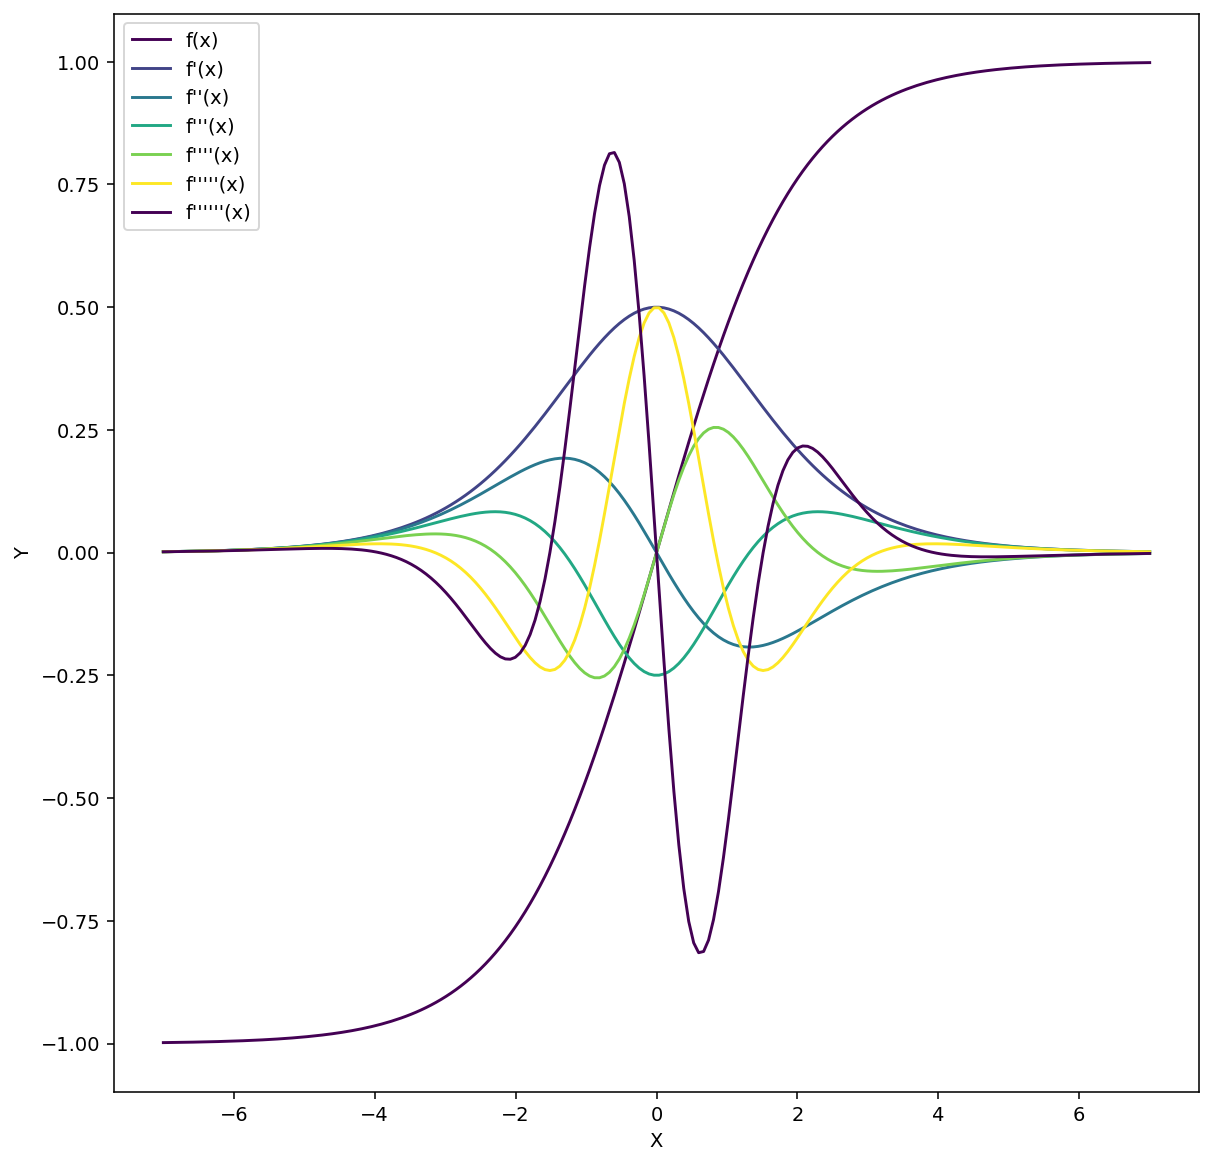

In [18]:

x = np.linspace(-7, 7, 200)          
gr = elementwise_grad
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
ax.plot(x, tanh(x),
          x, gr(tanh)(x),                                # first  derivative
          x, gr(gr(tanh))(x),                          # second derivative
          x, gr(gr(gr(tanh)))(x),                    # third  derivative
          x, gr(gr(gr(gr(tanh))))(x),              # fourth derivative
          x, gr(gr(gr(gr(gr(tanh)))))(x),        # fifth  derivative
          x, gr(gr(gr(gr(gr(gr(tanh))))))(x))  # sixth  derivative

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend(["f(x)", "f'(x)","f''(x)", "f'''(x)", "f''''(x)", "f'''''(x)", "f''''''(x)"])
plt.show()


In [19]:
# vector -> scalar runction

def tanh_sum_sqr(x, k):  # Define a function
    return np.tanh(np.sum(x**2)-k)

tanh_sum_sqr(np.array([-0.1, 0.2, 0.6]), 0.5)

-0.08975778474716013

In [20]:
grad_t_s_s = grad(tanh_sum_sqr) # function -> function

# differentiates w/respect to first arg. only
grad_t_s_s(np.array([-0.1, 0.2, 0.3]), 0.5)

array([-0.17616545,  0.35233091,  0.52849636])

### Vectorised example

In [21]:
# I do not fancy trying to differentiate this by hand
# (actually it's not that hard)
# (just really annoying)
f = np.array([[1, -0.2], [0.8, 1.5]])


def dog(x):
    x = x @ f
    return np.exp(-np.sum(x ** 2, axis=1) / 10.0) - np.exp(
        -np.sum(x ** 2, axis=1) / 2.0
    )


ddog = elementwise_grad(dog)  # compute derivative via autograd
# that is *literally* all that is required

In [22]:
## plot the results
# generate a grid to evaluate the function over
def show_fn(ax, fn, r, n_steps, d=None, contours=20):
    spacing = np.linspace(r[0], r[1], n_steps)
    mx, my = np.meshgrid(spacing, spacing)

    # rearrange the points into a Nx2 array
    pts = np.stack([mx.ravel(), my.ravel()]).T
    if d is None:
        mz = fn(pts).reshape(mx.shape)
    else:
        mz = fn(pts)[:, d].reshape(mx.shape)
    ax.pcolor(mx, my, mz)
    ax.contour(mx, my, mz, colors="k", linewidths=0.3, contours=contours)
    ax.set_aspect(1.0)

/tmp/ipykernel_5100/1093179204.py:14: UserWarning: The following kwargs were not used by contour: 'contours'
  ax.contour(mx, my, mz, colors="k", linewidths=0.3, contours=contours)


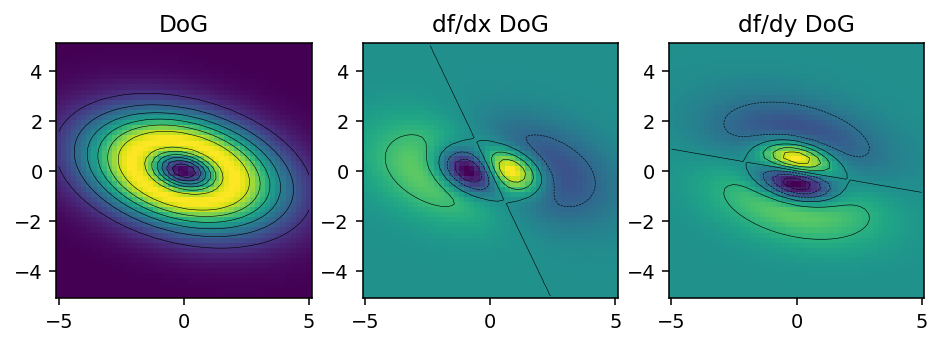

In [23]:
## plot the results
# generate a grid to evaluate the function over

# plot the results
fig = plt.figure()
ax = fig.add_subplot(1, 3, 1)
show_fn(ax, dog, [-5, 5], 50)
ax.set_title("DoG")
ax = fig.add_subplot(1, 3, 2)
show_fn(ax, ddog, [-5, 5], 50, d=0)
ax.set_title("df/dx DoG")
ax = fig.add_subplot(1, 3, 3)
show_fn(ax, ddog, [-5, 5], 50, d=1)
ax.set_title("df/dy DoG")
plt.show()

## Derivative tricks
[*Side note: if you have the gradient of a function, you can do nifty things like computing the light that would be reflected from the surface, given a fixed light source. This isn't directly important for IDSS, but shows how useful being able to differentiate functions is*]

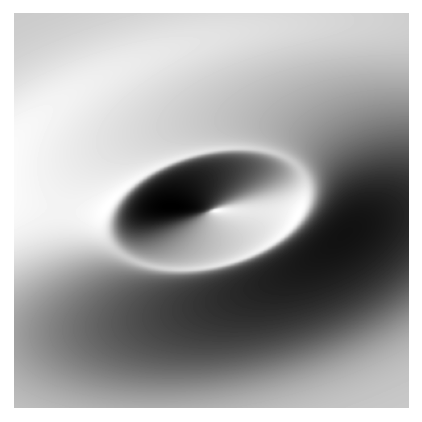

In [24]:
# You can ignore this if you want
# it just shows how the derivative can be useful
# in visualising a function, by computing lighting
# effects
fig = plt.figure()
ax = fig.add_subplot(1, 2, 1)
spacing = np.linspace(-4, 4, 300)
mx, my = np.meshgrid(spacing, spacing)
# rearrange the points into a Nx2 array
pts = np.stack([mx.ravel(), my.ravel()]).T

# stack up the gradient vectors
dzdx = ddog(pts)[:, 0]
dzdy = ddog(pts)[:, 1]
dzdz = np.ones_like(dzdy) * 0.08

grad_vec = np.stack([dzdx, dzdy, dzdz]).T
# normalise gradient vector
grad_vec = (grad_vec.T / (np.linalg.norm(grad_vec, axis=1))).T
# compute dot product with light vecotr
light_vec = np.array([0.5, 0.3, 0.5])
light = np.sum(grad_vec * light_vec / np.linalg.norm(light_vec), axis=1)

ax.imshow(light.reshape(mx.shape), cmap="gray")
ax.axis("off")
plt.show()

## Using autograd in optimisation

Using automatic differentiation, we can write down the form of the objective function as a straightforward computation, and get the derivatives of the function "for free". This makes it extremely efficient to perform first-order optimisation. 

This is what machine learning libraries do. They just make it easy to write vectorised, differentiable code that runs on GPU/TPU hardware. The rest is just dressing.

### Fitting a line, first-order
Let's re-solve the line of best fit from lecture 6. We want to find $m$ and $c$; the parameters of a line, such that the square difference between the line and a set of datapoints is minimised (the objective function).

In [25]:
## generate some random data, with a linear trend
# the linear regression problem; find m and c in the equation y=mx+c
from utils.history import linear_regression_plot

line_x = np.sort(np.random.normal(0, 1, (20,)))
gradient, offset = 2, 1  # these are the "true" parameters that generated this data

# 2x + 1 and a bit of noise
line_y = (
    gradient * line_x + offset + np.random.normal(0, 0.5 * np.abs(line_x), line_x.shape)
)

# loss function
def loss(theta):
    # sum of squares
    e = np.sum(((line_x * theta[0] + theta[1]) - 
                line_y) ** 2)
    return e

Here's the special bit:

In [26]:
#### new stuff
# compute derivative (in one step!)
dloss = grad(loss)


# optimise with gradient descent
grad_results = gradient_descent(loss, dloss,
                                np.array([-1.0,0.0]), 
                                0.01)
print(grad_results.iters)

32


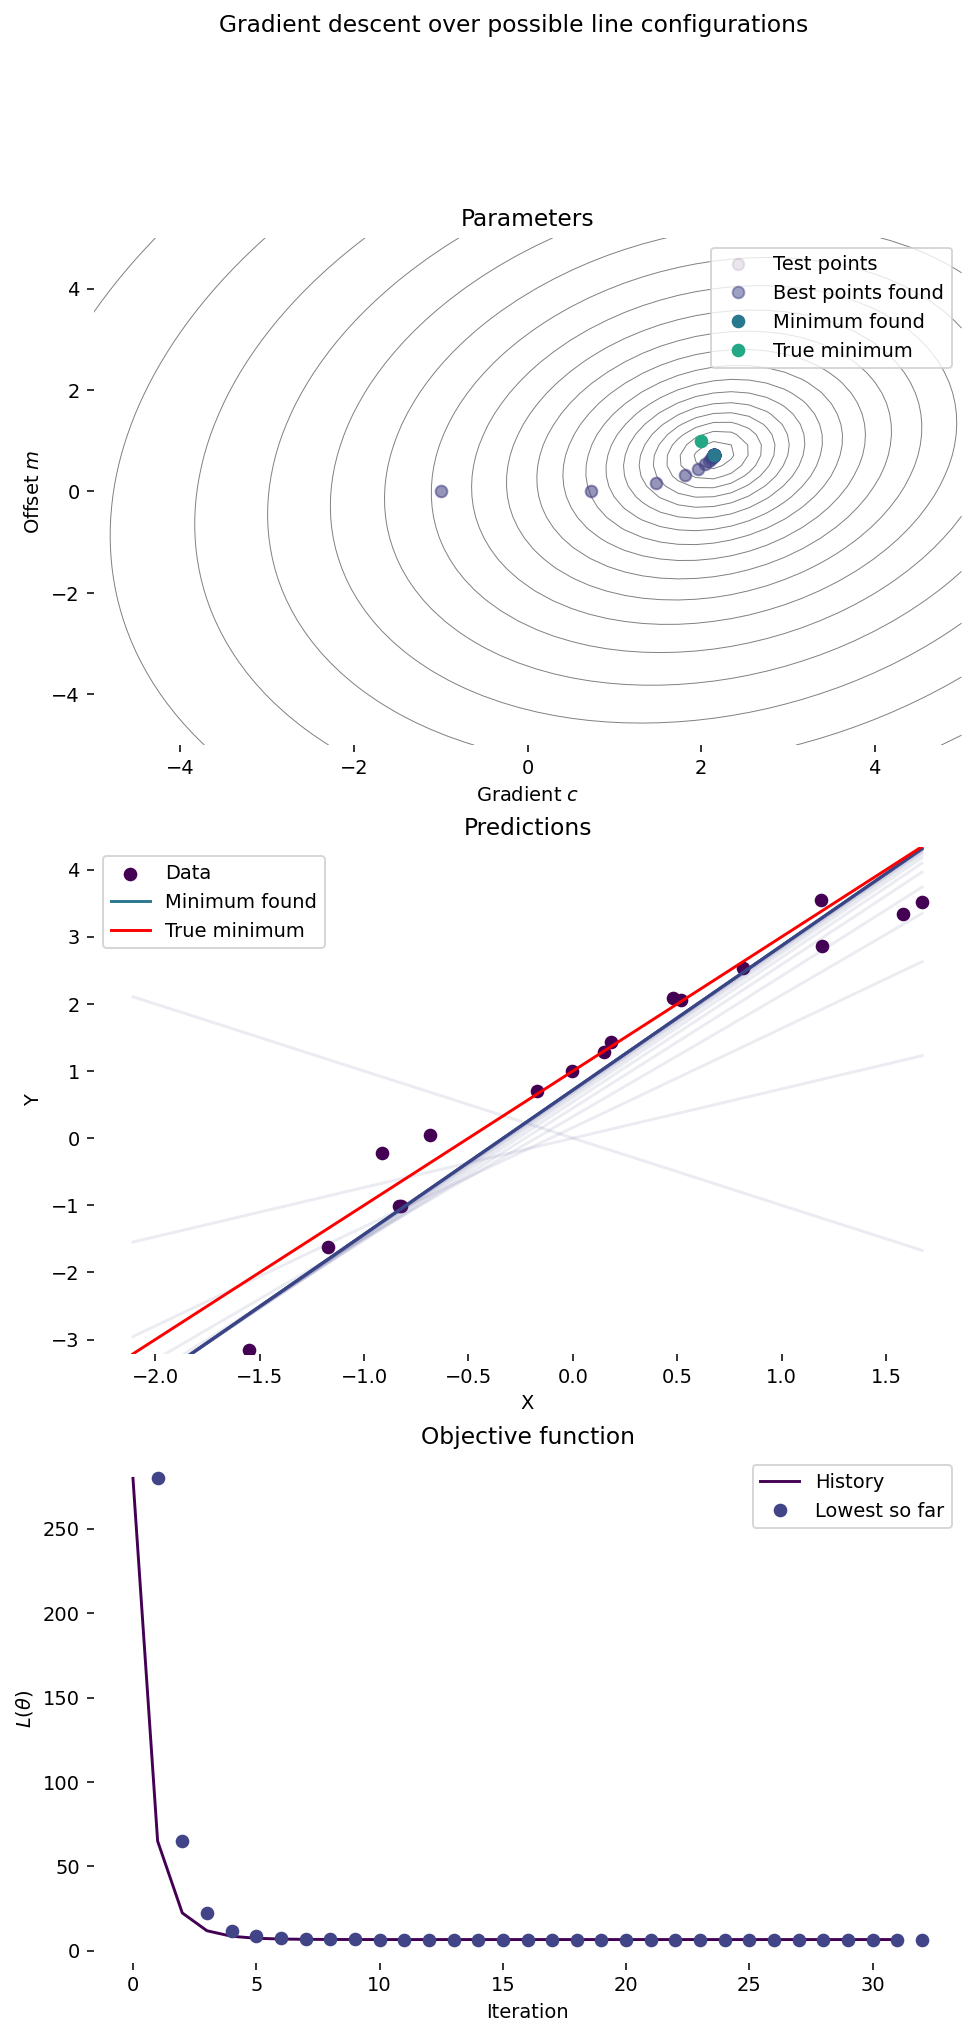

In [27]:
linear_regression_plot(grad_results, gradient, offset, line_x, 
                       line_y, opt_title="Gradient descent")
plt.show()


## Limits of automatic differentiation
Obviously, differentiation is only available for functions that are differentiable.  While first-order gradient vectors are often computable in reasonable time, as we'll see later it becomes very difficult to compute second derivatives of multidimensional functions. 

### Stochastic relaxation
How do animals evolve camouflage? This question is posed and discussed in **"The Blind Watchmaker"** by *Richard Dawkins*. Evolution is a gradual optimisation process, and to make steps that might be accepted requires that there is a smooth path from "poor fitness" to "good fitness".

<img src="imgs/moth.jpg" width="30%"> 

<br><br>*.[Image](https://flickr.com/photos/hpdpro/444942626 "camouflage") by [dano272](https://flickr.com/people/hpdpro) shared [CC BY-ND](https://creativecommons.org/licenses/by-nd/2.0/)*

So how can an animal like a moth evolve camouflage? It either gets eaten by a predator who sees it or the predator does not see it. This is binary function and has no gradient. While evolution requires no gradient, it does require that there be approximately continuous fitness functions.

### Resolution

The argument is that although every *specific* case is a simple binary choice, it is *averaged* over many random instances, where the conditions will be slightly different (maybe it is nearly dark, maybe the predator has bad eyes, maybe the weather is foggy) and averaging over all of those cases, some very minor change in colouring might offer an advantage. Mathematically speaking, this is **stochastic relaxation**; the apparently impossibly steep gradient has been rendered (approximately) Lipschitz continuous by integrating over many different random conditions.

This is applicable to many problems outside of evolution. For example, a very steep function has a very large derivative at some point; or it might have zero derivative in parts. But if we average over lots of cases where the step position is very slightly shifted, we get a smooth function.


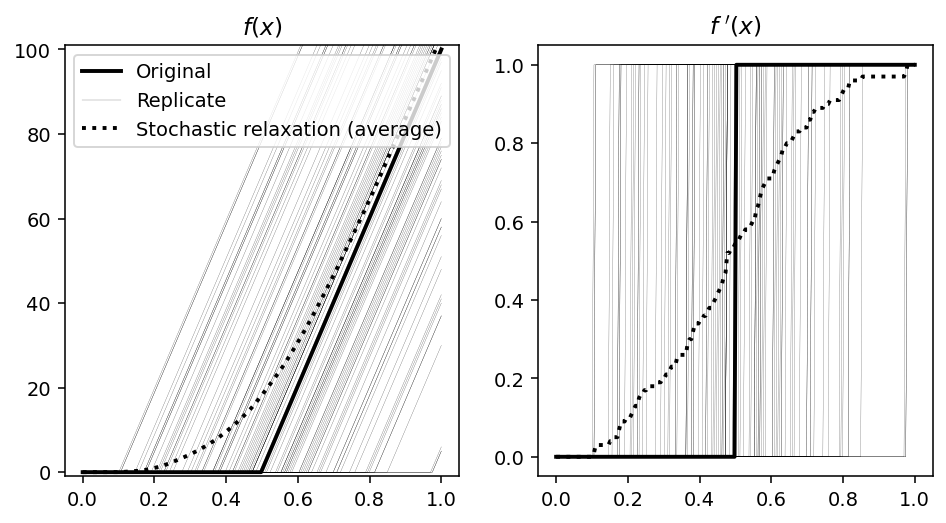

In [28]:
fig = plt.figure()
f_ax = fig.add_subplot(1,2,1)
d_ax = fig.add_subplot(1,2,2)

# hard step function
def step(x,t):
    return np.where(x>t, 1, 0)

xs = np.linspace(0,1,200)
fn = step(xs, 0.5)
f_ax.plot(xs, np.cumsum(fn), 'k', lw=2, label="Original")
d_ax.plot(xs, fn, 'k', lw=2, label="Original")
f_ax.set_title("$f(x)$")
d_ax.set_title("$f^{\ \prime}(x)$")


# but if we average it with slight shifts
# we get a function that is smoother
# we don't know the derivative exactly
# but that, it turns out, doesn't matter...
average_step = np.zeros_like(xs)
for i in range(100):
    offset = np.random.normal(0,0.2)
    rnd_step = step(xs, 0.5+offset)
    f_ax.plot(xs, np.cumsum(rnd_step), lw=0.1, c='k')
    d_ax.plot(xs, rnd_step, lw=0.1, c='k')
    average_step += rnd_step
f_ax.plot(xs, np.cumsum(rnd_step), lw=0.1, c='k', label="Replicate")    
d_ax.plot(xs, rnd_step, lw=0.1, c='k', label="Replicate")    
f_ax.set_ylim(-1,101)        
d_ax.plot(xs, average_step/100.0, 'k:', lw=2, label="Stochastic relaxation (average)")
f_ax.plot(xs, np.cumsum(average_step)/100.0, 'k:', lw=2, label="Stochastic relaxation (average)")
f_ax.legend(loc='upper center')
plt.show()


## Stochastic gradient descent
Gradient descent evaluates the objective function and its gradient at each iteration before making a step. This can be very expensive to do, particularly when optimising function approximations with large data sets (e.g. in machine learning). 

If the objective function can be broken down into small parts, the optimiser can do gradient descent on randomly selected parts independently, which may be much faster. This is called **stochastic gradient descent (SGD)**, because the steps it takes depend on the random selection of the parts of the objective function. 

This works if the objective function can be written as a sum:

$$L(\theta) = \sum_i L_i(\theta),$$
i.e. that the objective function is composed of the sum of many simple sub-objective functions $L_1(\theta), L_2(\theta), \dots, L_n(\theta)$.

This type of form often occurs when matching parameters to observations -- **approximation problems**, as in machine learning applications. In these cases, we have many **training examples** $\vec{x_i}$ with matching known outputs $y_i$, and we want find a parameter vector $\theta$ such that:

$$L(\theta) = \sum_i ||f(\vec{x_i};\vec{\theta}) - y_i||$$
is minimised, i.e. that the difference between the model output and the expected output is minimised, *summing over all training examples*. 

Differentiation is a linear operator. This means that we can interchange summation, scalar multiplication and differentiation $\frac{d}{dx}\left(a f(x)+ b g(x)\right) = a\frac{d}{dx}f(x) + b\frac{d}{dx}g(x)$, we have:

$$\nabla \sum_i ||f(\vec{x_i};\vec{\theta}) - y_i|| = \sum_i \nabla ||f(\vec{x_i};\vec{\theta}) - y_i||$$

In this case, we can take any *subset* of training samples and outputs, compute the gradient for each sample, then make a move according to the computed gradient of the subset. Over time, the random subset selection will (hopefully) average out. Each subset is called a **minibatch** and one run through the whole dataset (i.e. enough minibatches so that every data item has been "seen" by the optimiser) is called an **epoch**.

### Memory advantages

SGD has major advantages in terms of memory consumption, because computations can be applied to a small number of samples in **minibatches**. We just compute the gradient on a subsample, and move in that direction. It won't be *exactly* the right derivative of the whole objective function, but it will be a good approximation.

Particularly on memory-constrained devices such as GPUs (which might have only 12-16GB of RAM even for powerful GPUs), it can be impossible to store the entire dataset on the device. Splitting up into batches can get around this limitation. It can also have advantages with respect to the *memory hierarchy* -- small batches of data may induce fewer cache misses and thus result in enhanced performance.

### Heuristic enhancement
As well as plain memory efficiency, SGD can actually improve the performance of optimisation in terms of the objective function decrease, particularly by reducing the likelihood of getting stuck in minima. This is because the random partitioning of the objective function in each minibatch adds *noise* to the optimisation process. This might at first seem like a problem; we don't want the optimisation to be inaccurate. But noise means that there is a chance that gradient descent will *not* go downhill, but instead might go up hill and jump over a maxima.

While adding noise is a **heuristic search** approach (there is no guarantee it will make things better or even not make things worse), it is often very effective. We are essentially getting the benefits of a limited form of **stochastic relaxation** -- our objective function can be "smoothed out" by averaging over random subsamples, so even if it is not quite Lipschitz continuous (or has a bad Lipschitz constant), SGD can work well.

### Using SGD
There is no guarantee that SGD will even move in the right direction. In practice, it can be very efficient for many real world problems. For example, let's consider again the problem of fitting a line to observations (**linear regression**).

Given a set of pairs $x_i, y_i$, we want to find parameters $\vec{\theta} = [m,c]$ that minimise the squared error between the function $y^\prime=f(x;m,c)=mx+c$ and the true known output $y$. The objective function is:

$$\sum_i ||f(\vec{x_i};\vec{\theta}) - y_i||_2^2$$
$$=\sum_i ||(mx_i+c) - y_i||_2^2$$

Rather than computing the whole sum, we can compute the gradient on a **random** subset, and use this to compute the next step.

In [29]:
import autograd.numpy as np
def sgd(L, dL, theta_0, xs, ys, step=0.1, batch_size=10, epochs=10):
    """L: Objective function, in the form L(theta, xs, ys)
       dL: derivative of objective function in form dL(theta, xs, ys)
       theta_0: starting guess       
       xs: vector of inputs 
       ys: vector of outputs
       step: step size
       batch_size: batchsize
    """
    theta = np.array(theta_0)
    grad = np.zeros_like(theta_0)
    
    o = History()
    
    # One epoch is one run through the whole dataset
    for epoch in range(epochs):
        batch = np.arange(len(xs))
        # randomize order
        np.random.shuffle(batch)
        subset_index = 0        
        # iterate over subsets                
        
        ## One batch
        while subset_index + batch_size <= len(xs):                   
            
            # accumulate partial gradient            
            i,j = subset_index, subset_index+batch_size
            
            # compute gradient on the random subset
            # accumulating the gradient direction as we go
            grad = dL(theta, xs[batch[i:j]], ys[batch[i:j]])  / (j-i)    
            # next batch please!
            subset_index += batch_size            
            
            # make a step
            theta = theta - grad * step
            o.track(theta, L(theta, xs, ys))  
               
        #o.track(theta, L(theta, xs, ys))    
    return o.finalise()

### Linear regression with SGD
We can do our linear regression example with 10000 points - and find a good fit with *only one pass through the data*. This works because we can divide the problem up into a lots of sums of smaller problems (fitting a line on a few random points at a time) which are all part of one big problem (fitting a line to all of the points). 

When this is possible, it is vastly more efficient than computing the gradient for the entire set of data we have available.

In [30]:
# 100000 data points
xs = np.linspace(0,5, 100_000)
ys = xs  * 1.0 + 2.0
ys = ys + np.random.normal(0,0.5,xs.shape)

def linear_loss(theta,xs,ys):
    y_prime = theta[0] * xs + theta[1]        
    loss = np.sum((y_prime-ys)**2)    
    return loss

def linear_dloss(theta,xs,ys):            
    return grad(lambda x:linear_loss(x,xs,ys))(theta)


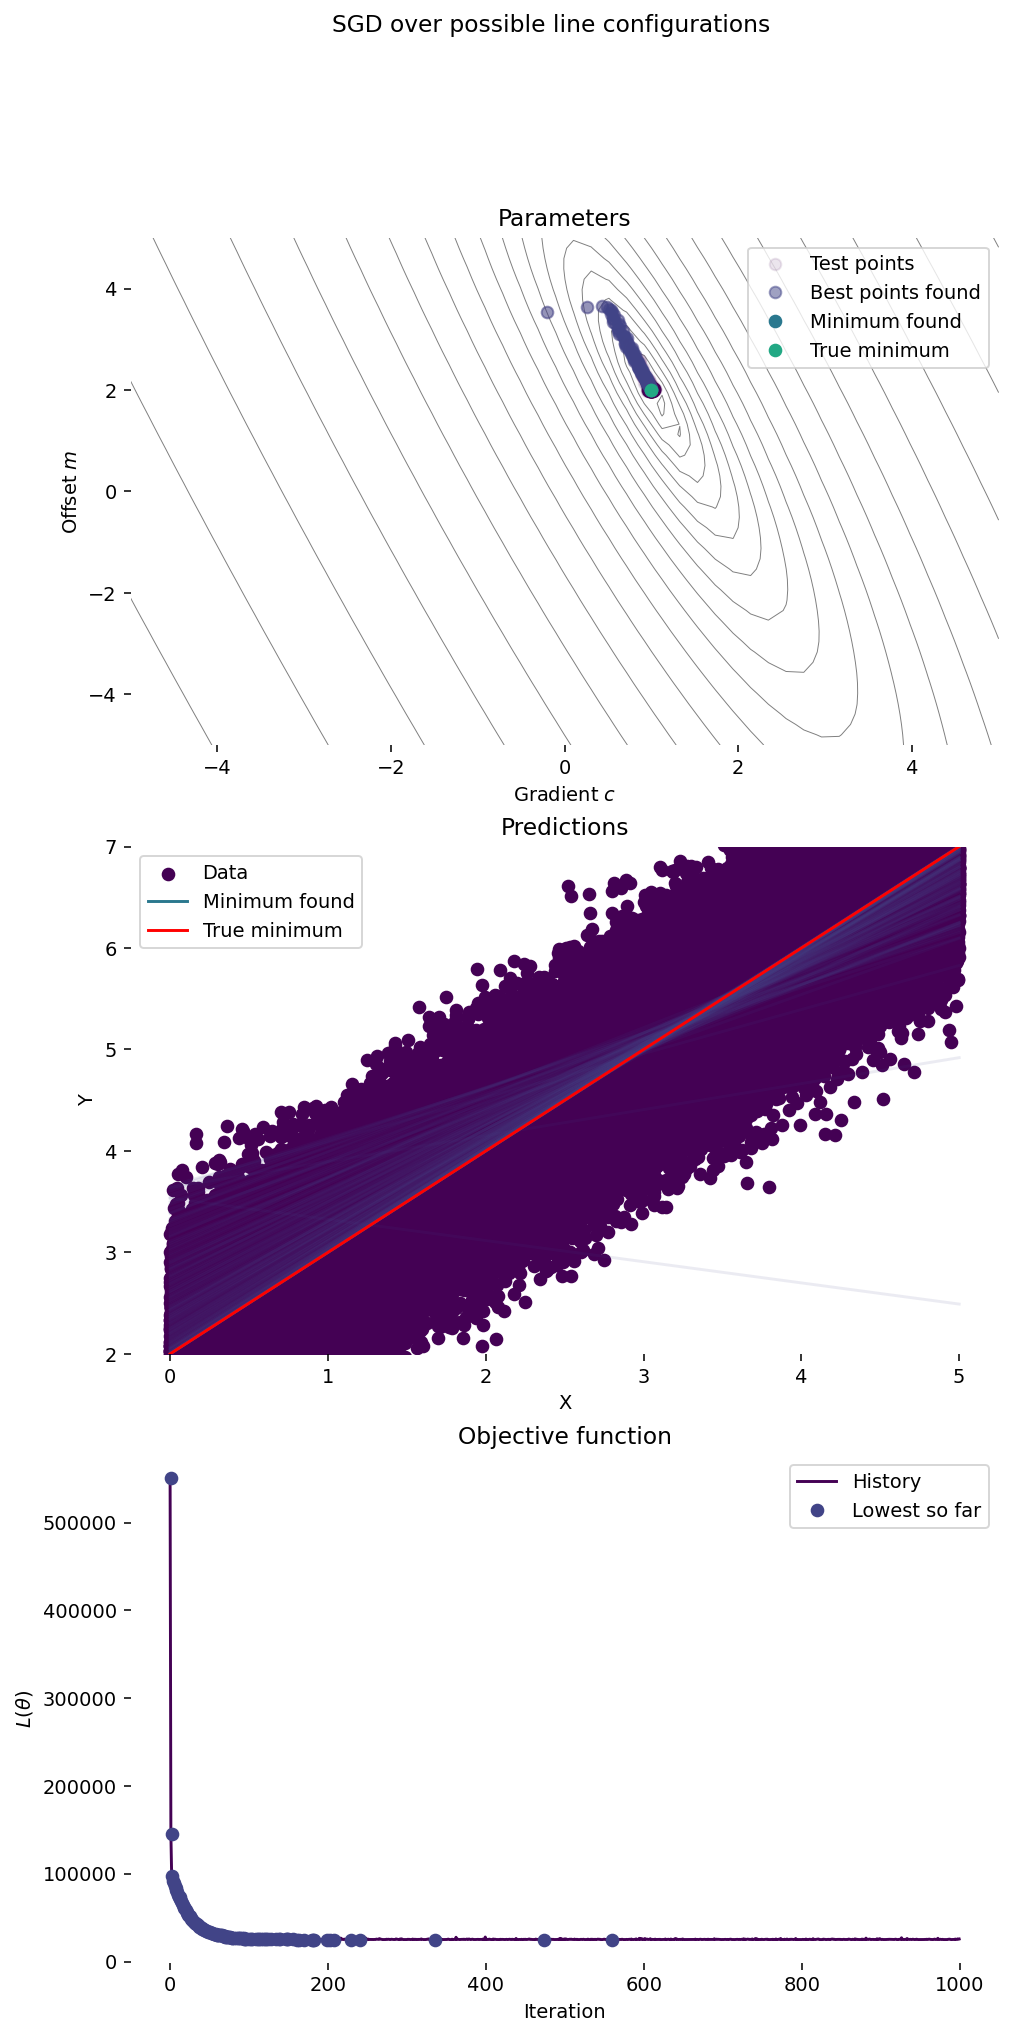

In [31]:

res = sgd(linear_loss, grad(linear_loss), [-3.5, 2.5], xs, ys, 
          batch_size=100, epochs=1, step=0.05)

linear_regression_plot(res, 1.0, 2.0, xs, ys, 'SGD')
plt.show()

## A nightmare function

This function has it all:
* narrow valleys everywhere
* multiple local minima
* a huge ridge through the middle

Gradient descent is hopeless -- it gets stuck in a valley an wanders in a huge arc, never approaching even the local minima.

In [32]:
# this function is crazy
# don't worry about how it is defined
# it is designed to be horrible, not realistic
def bad_function(theta):
    if len(theta.shape)==1:
        theta = theta[None,:]
    ctr = np.array([-2, 3])
    false_ctr = np.array([3,0.5])
    loss = -np.exp(-(np.sum((theta-ctr)**2, axis=1)/20.0))
    loss = loss + np.exp(-(np.sum((theta+ctr)**2, axis=1)/20.0))
    loss = loss + np.cos(np.linalg.norm(theta+false_ctr, ord=2, axis=1)*6)*0.08    
    loss = loss - np.exp(-(np.sum((theta-false_ctr)**2, axis=1)/5.0))*0.75
    loss = loss - np.exp(-(np.sum((theta+false_ctr)**2, axis=1)/2.0))*0.75
    loss = loss + np.exp(-((theta[:,1]+1)**2)*2)    
    return loss

Let's see what gradient descent does:

/tmp/ipykernel_5100/1093179204.py:14: UserWarning: The following kwargs were not used by contour: 'contours'
  ax.contour(mx, my, mz, colors="k", linewidths=0.3, contours=contours)


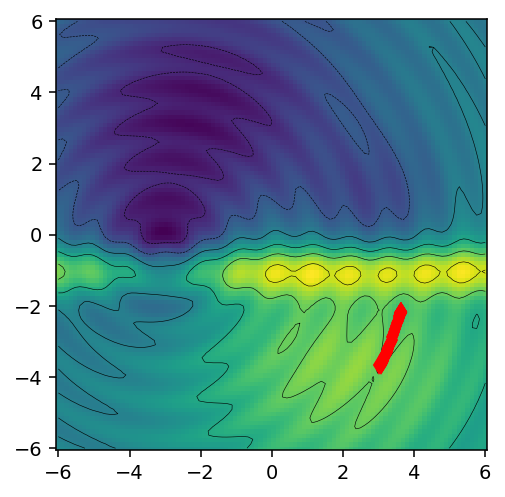

In [33]:
# differentiate and do gradient descent
dbad_function = elementwise_grad(bad_function)
res = gradient_descent(bad_function, dbad_function, np.random.normal(0,4,2), 0.5)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
show_fn(ax, bad_function, (-6,6), 100, contours=50)
ax.set_aspect(1.0)

plt.plot(res.all_theta[:,0], res.all_theta[:,1], 'rd')
plt.show()
    
    

Gradient descent cannot do a good job. Adjusting the step size can't help; the problem isn't that we've chosen a bad step size. **Stochastic gradient descent** can't help; we don't have an objective function which is a simple sum of sub-objective functions. What can we do?

## Random restart
Gradient descent gets trapped in minima easily. Once it is in an **attractor basin** of a **local minima** it can't easily get out. SGD can add a little bit of noise that might push the optimiser over small ridges and peaks, but not out of deep minima. A simple heuristic is just to run gradient descent until it gets stuck, then randomly restart with different initial conditions and try again. This is repeated a number of times, hopefully with one of the optimisation paths ending up in the global minimum. This metaheuristic works for any local search method, including hill climbing, simulated annealling, etc.

## Simple memory: momentum terms
A physical ball rolling on a surface is not stopped by a small irregularity in a surface. Once it starts rolling downhill, it can skip over little bumps and divots, and cross flat plains, and head steadily down narrow valleys without bouncing off the edges. This is because it has **momentum**; it will tend to keep going in the direction it was just going. This is a form of the memory metaheuristic. Rather than having ant-colony style paths everywhere, the optimiser just remembers one simple path -- the way it is currently going.

The same idea can be used to reduce the chance of (stochastic) gradient descent becoming trapped by small fluctuations in the objective function and "smooth" out the descent. The idea is simple; if you are going the right way now, keep going that way even if the gradient is not always quite downhill.

We introduce a velocity $v$, and have the optimiser move in this direction. We gradually adjust $v$ to align with the derivative.

$$
v = \alpha v + \delta \nabla L(\theta)\\
\theta^{(i+1)} = \theta^{(i)} - v\\
$$

This is governed by a parameter $\alpha$; the closer to $\alpha$ is to 1.0 the more momentum there is in the system. $\alpha=0.0$ is equivalent to ordinary gradient descent.


In [34]:
def gradient_descent_restart_momentum(L, dL, sample_fn, delta, 
                                      alpha=0.9, restarts=20, 
                                      tol=1e-4):    
    o = History()    
    # retry a number of times
    for i in range(restarts):  
        # copy theta_0 
        theta = np.array(sample_fn())           
        o.loss_change = np.inf # force the optimiser to restart
        
        # while the loss changes
        vel = dL(theta)
        while np.abs(o.loss_change)>tol:
            
            # accumulate velocity "keep on rollin'"
            vel = alpha * vel +  delta * dL(theta)
            # make a step along the velocity
            theta -= vel                    
            o.track(np.array(theta), L(theta))    
            
        # force a break in the plot
        o.track(np.full(theta.shape, np.nan), L(theta))
    return o.finalise()

/tmp/ipykernel_5100/1093179204.py:14: UserWarning: The following kwargs were not used by contour: 'contours'
  ax.contour(mx, my, mz, colors="k", linewidths=0.3, contours=contours)


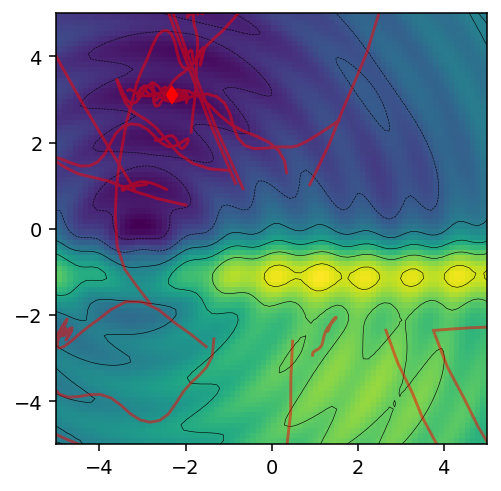

In [35]:
### now plot the trace with momentum and restarts

res = gradient_descent_restart_momentum(
    bad_function, dbad_function, lambda:np.random.normal(0,2,2), 
    delta=0.2, alpha=0.9)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
show_fn(ax, bad_function, (-6,6), 100, contours=50)
ax.set_aspect(1.0)
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.plot(res.all_theta[:,0], res.all_theta[:,1], 'r', alpha=0.5)
ax.plot(res.best_theta[0], res.best_theta[1], 'rd')
plt.show()

----

# Types of critical points
This physical surface intuition leads us to think of how we would characterise different parts of an objective function. 

For smooth, continuous objective functions, there are various points in space of particular interest. These are **critical points**, where the gradient vector components is the zero vector.
<img src="imgs/optima.png" width="50%">
*Image: classification of critical points. Each of these corresponds to a different configuration of the eigenvalues of the **Hessian**.*




## Second-order derivatives
If the first order derivatives represent the "slope" of a function, the second order derivatives represent the "curvature" of a function.

For every parameter component $\theta_i$ the Hessian stores how the *steepness* of every other $\theta_j$ changes.


Imagine I am on a hill. 
* The altitude I am at is the value of the objective function. 
* The parameters I can vary are my position North/South and East/West. 
* The gradient vector is the change in altitude as I take a step North or a step East, which are the two parameters. This is the local steepness at the place I am at on the hill. 
* The Hessian captures how much steeper the hill get stepping Northwards as I go North and *also* how much steeper the hill gets Eastwards as I step North; similarly for stepping East. So there is a 2x2 matrix describing these changes in steepness.

For a vector valued function $f(\vec{x})$, then we have:
$$
\nabla L(\vec{\theta}) = \left[ \frac{\partial L(\vec{\theta})}{\partial \theta_1},  
\frac{\partial L(\vec{\theta})}{\partial \theta_2}, \dots, \frac{\partial L(\vec{\theta})}{\partial \theta_n}\right],
$$
the gradient vector, and the second order derivatives are captured by
$$
\begin{equation}
\nabla \nabla L(\vec{\theta}) = \nabla^2 L(\vec{\theta}) = 
\begin{bmatrix}
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_1^2} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_1\partial \theta_2} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_1\partial \theta_3} & \dots &
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_1\partial \theta_n}\\
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_2\partial\theta_1} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_2^2} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_2\partial \theta_3} & \dots &
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_2\partial \theta_n}\\
\dots\\
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_n\partial\theta_1} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_n\partial \theta_2} & 
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_n\partial \theta_3} & \dots &
\frac{\partial^2 L(\vec{\theta})}{\partial \theta_n^2}\\
\end{bmatrix},
\end{equation}
$$
the **Hessian matrix**. Note that we have an entry in the Hessian matrix for every *pair of dimensions* in the function. You might notice the similarity to the covariance matrix, which captured how data coordinates varied with each other; the Hessian matrix captures how gradients of a function vary with each other.

For a 2D surface, the gradient vector specifies the normal of the plane tangent to the surface at a given point. The Hessian matrix specifies a quadratic function (a smooth curve with one minima) following the curvature of the surface.


### Eigenvalues of the Hessian 
The Hessian matrix captures important properties about the **type of critical point** that we saw in the previous lecture. In particular, the **eigenvalues** of the Hessian tell us what kind of point we have.

* If all eigenvalues are all strictly positive, the matrix is called **positive definite** and the point is a minimum.
* If all eigenvalues are all strictly negative (**negative definite**) and the point is a maximum.
* If eigenvalues have mixed sign the point is a saddle point.
* If the eigenvalues are all positive/negative, but with some zeros, the matrix is **semidefinite** and the point is plateau/ridge.

## Second-order optimisation
Second-order optimisation uses the Hessian matrix to jump to the bottom of each local quadratic approximation in a single step.  This can skip over flat plains and escape from saddle points that slow down gradient descent. Second-order methods are *much* faster in general than first-order methods. 

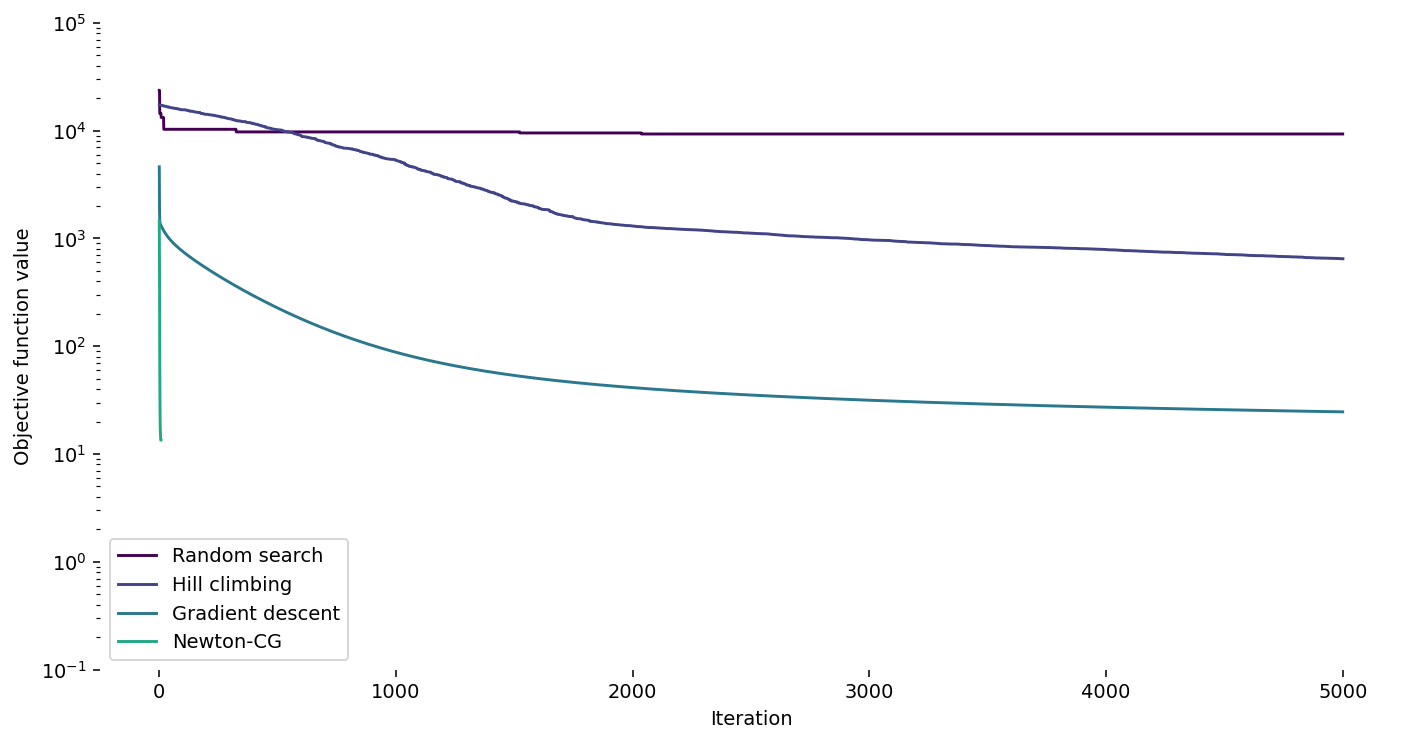

In [36]:
from autograd import grad, jacobian
from utils.optimisers import random_search, hill_climbing,  gradient_descent
import scipy.optimize
import autograd.numpy as np

# the linear regression problem; find m and c in the equation y=mx+c
dim = 15
x = np.sort(np.random.normal(0,1,(20,dim)))
A = np.random.normal(0,1,(dim,dim))
b = np.random.normal(0,10,(dim,))

y = (x@A) + b + np.random.normal(0, 0.5*np.abs(x), x.shape) 
l = len(A.ravel())
params = l + len(b)
%matplotlib inline
%matplotlib inline

import matplotlib.pyplot as plt

def loss(theta):
    # sum of squares    
    Ap = theta[:l].reshape(A.shape)
    bp = theta[l:]
    
    e = np.sum(((x @ Ap + bp) - y)**2)    
    return e

# compute derivative (in one step!)
dloss = grad(loss)

guess = lambda: np.random.normal(0, 1, params)
neighbour = lambda x: x+np.random.normal(0, 0.01, params)

random_res = random_search(loss, guess, 5000)
hill_res = hill_climbing(loss, guess, neighbour, 5000)

gd_res = gradient_descent(loss, dloss, guess(), 1e-3, maxiter=5000)

ncg_trace = []
def record_trace(x):    
    ncg_trace.append(loss(x))
ncg_res = scipy.optimize.minimize(fun=loss, 
                                  x0=guess(), 
                                  callback=record_trace, 
                                  method='Newton-CG', 
                                  jac=grad(loss), 
                                  hess=jacobian(grad(loss)))


fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1,1,1)
ax.plot(random_res.loss_trace, label="Random search")
ax.plot(hill_res.loss_trace, label="Hill climbing")
ax.plot(gd_res.loss_trace, label="Gradient descent")
ax.plot(ncg_trace, label="Newton-CG")

ax.set_frame_on(False)
ax.set_yscale("log")
ax.set_ylim(1e-1, 1e5)
ax.legend()
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective function value")
plt.show()

#### Curse of dimensionality (yet again)
However, simple second order methods don't work in high dimensions. Evaluating the Hessian matrix requires $d^2$ computations, and $d^2$ storage. Many machine learning applications have models with $d>$ 1 million parameters. Just storing the Hessian matrix for *one iteration* of the optimisation would require:

**Second order optimisation** can move much more quickly through saddle points and plateaus than first order methods like gradient descent. It can be particularly effective in low-dimensional problems, but the **curse of dimensionality** always has its way. Imagine we have a 1 million parameter problem to optimise. The gradient vector would have as many elements as the parameter vector; so 1 million elements, or about 8 megabytes of memory requirement for `float64`. But the Hessian matrix has to store the change in every *pair* of parameters. This would take:

In [37]:
print("{0} bytes of memory".format(1000000 * 1000000 * 8)) # 8 bytes per float

8000000000000 bytes of memory


which is 8 terabytes! This is an impossible computational burden. There are special, limited-memory forms of second order methods, which use approximate Hessians (like the widely used L-BFGS algorithm) but these are outside the scope of this course.


## Resources

* [**How machines learn**](https://www.youtube.com/watch?v=IHZwWFHWa-w) **Recommended: WATCH THIS**
* [**What is backpropagation**](https://www.youtube.com/watch?v=Ilg3gGewQ5U) if you want more detail on how first-order optimisation is used in deep learning.
* [**Gradient based optimization**](https://exploringpirate.wordpress.com/2017/08/16/gradient-based-optimization/)
* [**An overview of gradient descent optimization algorithms**](http://ruder.io/optimizing-gradient-descent/index.html#gradientdescentvariants)
* [**An introduction to algorithms for continuous optimization**](http://www.numerical.rl.ac.uk/people/nimg/course/lectures/paper/paper.pdf) by Nicholas Gould